In [ ]:
# Base Geneformer V2 embeddings
# vs
# Model 1 embeddings
# vs
# Model 2 embeddings

In [ ]:
from pathlib import Path
import os

os.environ["WANDB_DISABLED"] = "true"

PROJECT_DIR = Path()

# Stage 1 tokenized dataset
STAGE1_TOKENIZED_DATASET = (
    PROJECT_DIR
    / "tokenized_data"
    / "01_primary_celltype"
    / "01_primary_celltype.dataset"
)

# Stage 2 tokenized dataset
STAGE2_TOKENIZED_DATASET = (
    PROJECT_DIR
    / "tokenized_data"
    / "02_disease"
    / "02_disease.dataset"
)

# Model run folders
STAGE1_RUN_DIR = (
    PROJECT_DIR
    / "runs_geneformer_v2"
    / "01_primary_celltype"
)

STAGE2_RUN_DIR = (
    PROJECT_DIR
    / "runs_geneformer_v2"
    / "02_disease"
)

# Output folders
EMBED_DIR = PROJECT_DIR / "embedding_analysis"

STAGE1_EMBED_DIR = EMBED_DIR / "stage1_celltype_model"
STAGE2_EMBED_DIR = EMBED_DIR / "stage2_disease_model"

for folder in [
    EMBED_DIR,
    STAGE1_EMBED_DIR,
    STAGE2_EMBED_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Stage 1 tokenized dataset:")
print(STAGE1_TOKENIZED_DATASET)

print("\nStage 2 tokenized dataset:")
print(STAGE2_TOKENIZED_DATASET)

print("\nExistence checks:")
print("Stage 1 dataset:", STAGE1_TOKENIZED_DATASET.exists())
print("Stage 2 dataset:", STAGE2_TOKENIZED_DATASET.exists())
print("Stage 1 run dir:", STAGE1_RUN_DIR.exists())
print("Stage 2 run dir:", STAGE2_RUN_DIR.exists())

In [ ]:
#load both models

# Stage 1 model
with open(STAGE1_RUN_DIR / "MODEL_STAGE1_PATH.txt") as f:
    MODEL_STAGE1 = Path(f.read().strip())

# Stage 2 model
with open(STAGE2_RUN_DIR / "MODEL_STAGE2_PATH.txt") as f:
    MODEL_STAGE2 = Path(f.read().strip())

print("Stage 1:")
print(MODEL_STAGE1)

print("\nExists:", MODEL_STAGE1.exists())

print("\nStage 2:")
print(MODEL_STAGE2)

print("\nExists:", MODEL_STAGE2.exists())

In [ ]:
#inspect class mapping
import pickle

STAGE1_ID_CLASS_FILE = (
    STAGE1_RUN_DIR / "01_primary_celltype_id_class_dict.pkl"
)

STAGE2_ID_CLASS_FILE = (
    STAGE2_RUN_DIR / "02_disease_id_class_dict.pkl"
)

with open(STAGE1_ID_CLASS_FILE, "rb") as f:
    stage1_id_class_dict = pickle.load(f)

with open(STAGE2_ID_CLASS_FILE, "rb") as f:
    stage2_id_class_dict = pickle.load(f)

print("Stage 1 class mapping:")
print(stage1_id_class_dict)

print("\nStage 2 class mapping:")
print(stage2_id_class_dict)

N_STAGE1_CLASSES = len(stage1_id_class_dict)
N_STAGE2_CLASSES = len(stage2_id_class_dict)

print("\nStage 1 classes:", N_STAGE1_CLASSES)
print("Stage 2 classes:", N_STAGE2_CLASSES)

In [ ]:
#inspect closely
from datasets import load_from_disk

ds1 = load_from_disk(str(STAGE1_TOKENIZED_DATASET))
ds2 = load_from_disk(str(STAGE2_TOKENIZED_DATASET))

print("Stage 1")
print(ds1)
print(ds1.column_names)

print("\nExample record:")
print(ds1[0].keys())

print("\n---------------------------\n")

print("Stage 2")
print(ds2)
print(ds2.column_names)

print("\nExample record:")
print(ds2[0].keys())

In [ ]:
#extract embedding Stage 1
from geneformer import EmbExtractor

stage1_extractor = EmbExtractor(
    model_type="CellClassifier",
    num_classes=N_STAGE1_CLASSES,
    emb_mode="cell",
    max_ncells=None,
    emb_layer=-1,
    emb_label=[
        "cell_id",
        "individual",
        "celltype",
        "disease",
    ],
    forward_batch_size=8,
    nproc=4,
    model_version="V2",
)

print("Stage 1 embedding extractor initialized.")

In [ ]:
# no cell limit! using only 8 GB of Memory
stage1_embeddings = stage1_extractor.extract_embs(
    model_directory=str(MODEL_STAGE1),
    input_data_file=str(STAGE1_TOKENIZED_DATASET),
    output_directory=str(STAGE1_EMBED_DIR),
    output_prefix="stage1_celltype_embeddings",
)

print("Stage 1 embeddings extracted.")
print(stage1_embeddings.shape)

display(stage1_embeddings.head())

In [ ]:
#also

print("Files produced:")

for f in sorted(STAGE1_EMBED_DIR.iterdir()):
    print(f.name)

In [ ]:
#build AnnData
import scanpy as sc

# Keep Scanpy plots compact for notebook viewing
sc.settings.set_figure_params(dpi=100, dpi_save=100)
import numpy as np

# Embedding columns
embedding_cols = [str(i) for i in range(768)]

# Some versions return integer column names
if 0 in stage1_embeddings.columns:
    embedding_cols = list(range(768))

X = stage1_embeddings[embedding_cols].to_numpy(dtype=np.float32)

obs = stage1_embeddings[
    ["cell_id", "individual", "celltype", "disease"]
].copy()

obs.index = obs["cell_id"]

adata_stage1 = sc.AnnData(
    X=X,
    obs=obs
)

print(adata_stage1)

In [ ]:
donor_sizes = (
    adata_stage1.obs["individual"]
    .value_counts()
)

adata_stage1.obs["donor_size"] = (
    adata_stage1.obs["individual"]
    .map(donor_sizes)
)

In [ ]:
#compute neighbors
sc.pp.neighbors(
    adata_stage1,
    use_rep="X",
    metric="cosine",
    n_neighbors=15
)

In [ ]:
#umap
sc.tl.umap(
    adata_stage1,
    random_state=42
)

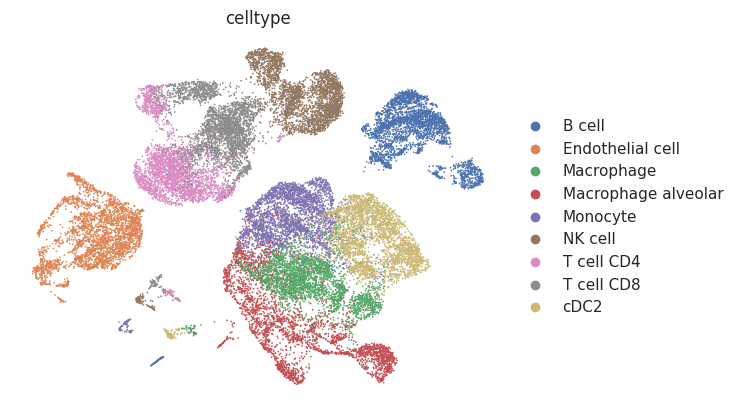

In [ ]:
#color it 
sc.pl.umap(
    adata_stage1,
    color="celltype",
    frameon=False,
    size=6
)

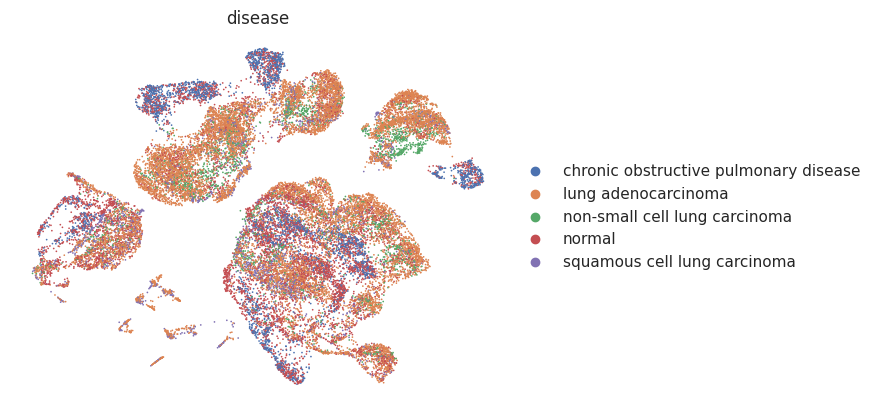

In [ ]:
#color by disease
sc.pl.umap(
    adata_stage1,
    color="disease",
    frameon=False,
    size=6
)

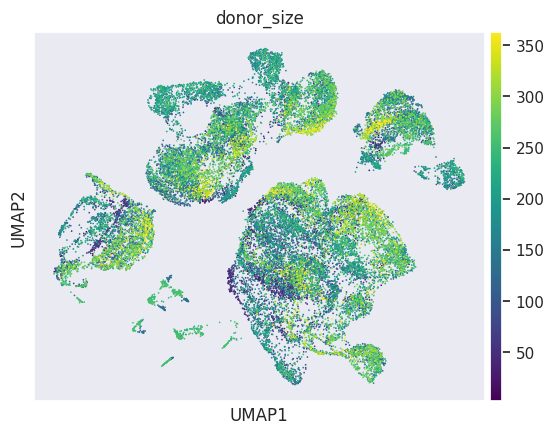

In [ ]:
sc.pl.umap(
    adata_stage1,
    color="donor_size",
    cmap="viridis",
    size=6
)

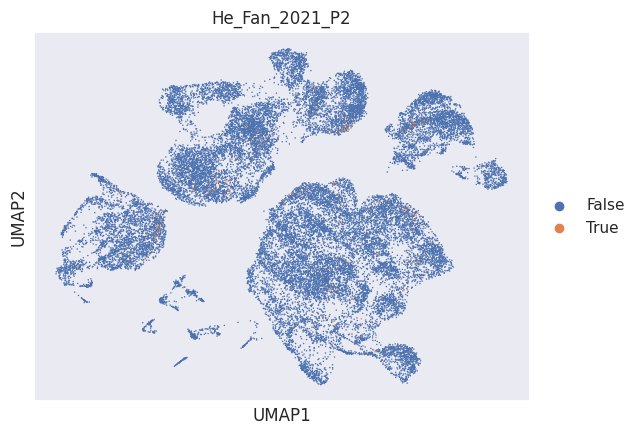

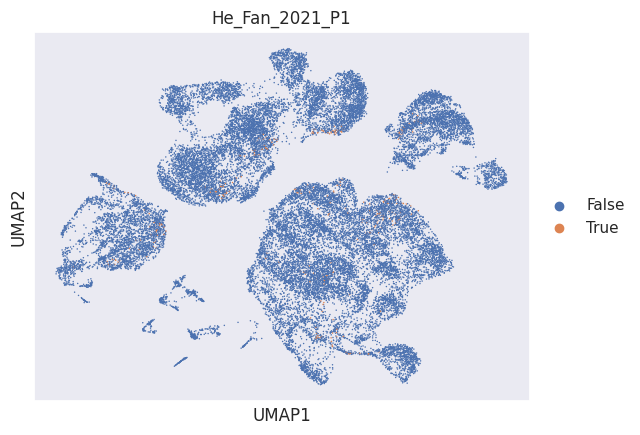

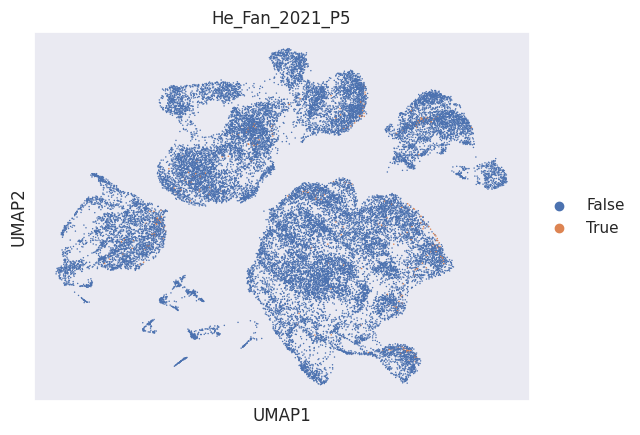

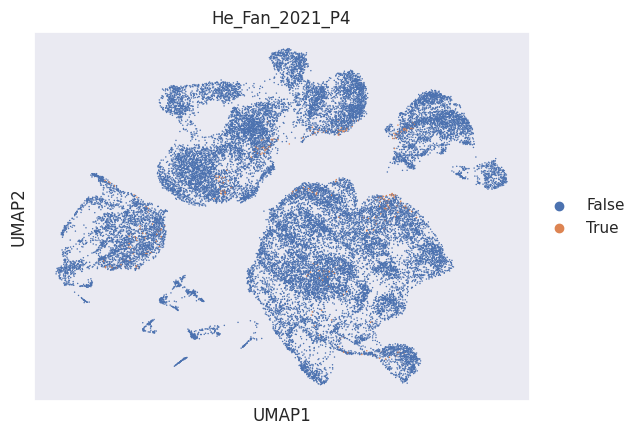

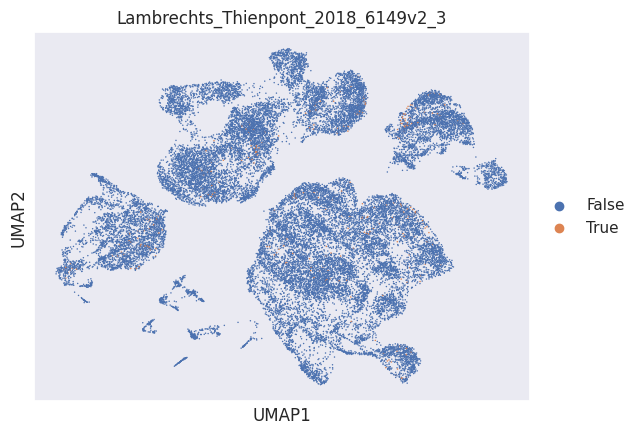

In [ ]:
#top 5 donors
top5 = (
    adata_stage1.obs["individual"]
    .value_counts()
    .head(5)
    .index
)

for donor in top5:

    adata_stage1.obs["is_donor"] = (
        adata_stage1.obs["individual"] == donor
    )

    sc.pl.umap(
        adata_stage1,
        color="is_donor",
        title=donor
    )

In [ ]:
from sklearn.metrics import silhouette_score

print("Calculating silhouette scores...")

celltype_score = silhouette_score(
    adata_stage1.X,
    adata_stage1.obs["celltype"],
    metric="cosine"
)

disease_score = silhouette_score(
    adata_stage1.X,
    adata_stage1.obs["disease"],
    metric="cosine"
)

donor_score = silhouette_score(
    adata_stage1.X,
    adata_stage1.obs["individual"],
    metric="cosine"
)

print(f"Cell type silhouette : {celltype_score:.3f}")
print(f"Disease silhouette   : {disease_score:.3f}")
print(f"Donor silhouette     : {donor_score:.3f}")

In [ ]:
import pandas as pd
from pathlib import Path

MASTER_TABLE = EMBED_DIR / "embedding_master_table.csv"

new_row = pd.DataFrame({
    "Model": ["Stage 1 Cell-type"],
    "Model_Version": ["Geneformer V2"],
    "Training_Task": ["9-class cell type classification"],
    "Training_Dataset": ["01_primary_celltype"],
    "Number_of_Cells": [27000],
    "Number_of_Classes": [9],
    "Learning_Rate": [1e-4],
    "Epochs": [1],
    "Frozen_Layers": [6],
    "Train_Batch_Size": [8],
    "Forward_Batch_Size": [16],
    "Celltype_Silhouette": [round(celltype_score, 3)],
    "Disease_Silhouette": [round(disease_score, 3)],
    "Donor_Silhouette": [round(donor_score, 3)],
    "Notes": ["Initial cell-type fine-tuning"]
})

if MASTER_TABLE.exists():
    master = pd.read_csv(MASTER_TABLE)

    # Replace existing row when notebook is rerun
    master = master[master["Model"] != "Stage 1 Cell-type"].copy()

    master = pd.concat(
        [master, new_row],
        ignore_index=True
    )
else:
    master = new_row

master = master.sort_values("Model").reset_index(drop=True)

master.to_csv(
    MASTER_TABLE,
    index=False
)

display(master)

print("Master table saved to:")
print(MASTER_TABLE)

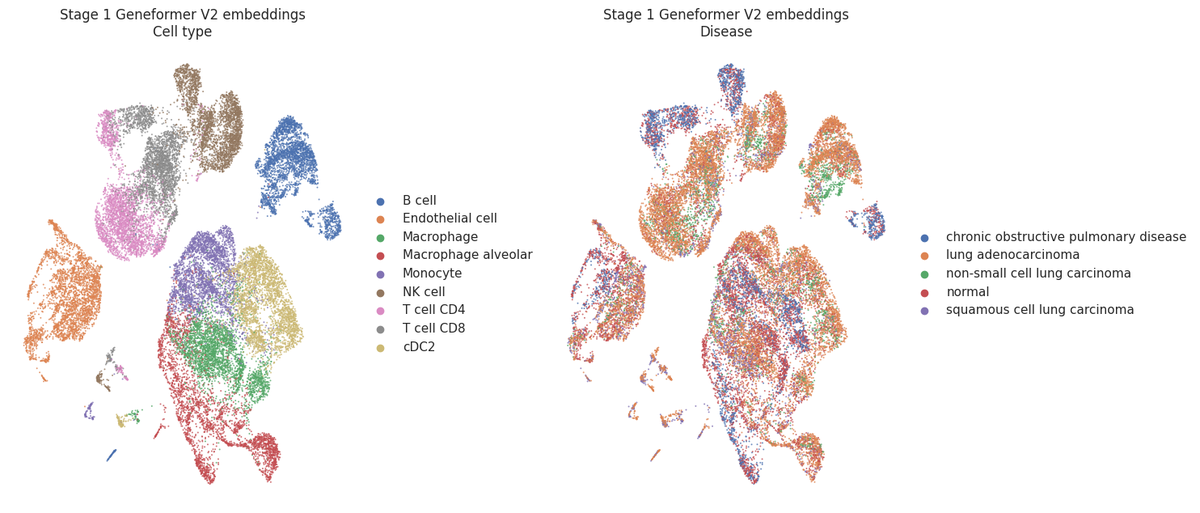

In [ ]:
#high quality umap
import scanpy as sc
import matplotlib.pyplot as plt

# Screen-friendly figures for notebooks and Git review
LOW_RES_DPI = 100
plt.rcParams.update({
    "figure.dpi": LOW_RES_DPI,
    "savefig.dpi": LOW_RES_DPI,
})
from pathlib import Path

FIG_DIR = EMBED_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Recalculate graph/UMAP only if missing
if "neighbors" not in adata_stage1.uns:
    sc.pp.neighbors(
        adata_stage1,
        n_neighbors=20,
        metric="cosine",
        use_rep="X",
        random_state=42,
    )

if "X_umap" not in adata_stage1.obsm:
    sc.tl.umap(
        adata_stage1,
        min_dist=0.25,
        spread=1.0,
        random_state=42,
    )

# Ensure categorical ordering is stable
adata_stage1.obs["celltype"] = adata_stage1.obs["celltype"].astype("category")
adata_stage1.obs["disease"] = adata_stage1.obs["disease"].astype("category")

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

sc.pl.umap(
    adata_stage1,
    color="celltype",
    ax=axes[0],
    show=False,
    frameon=False,
    size=8,
    alpha=0.8,
    title="Stage 1 Geneformer V2 embeddings\nCell type",
    legend_loc="right margin",
)

sc.pl.umap(
    adata_stage1,
    color="disease",
    ax=axes[1],
    show=False,
    frameon=False,
    size=8,
    alpha=0.8,
    title="Stage 1 Geneformer V2 embeddings\nDisease",
    legend_loc="right margin",
)

plt.tight_layout()

pdf_file = FIG_DIR / "stage1_umap_celltype_disease.pdf"
png_file = FIG_DIR / "stage1_umap_celltype_disease.png"

plt.savefig(pdf_file, dpi=100, bbox_inches="tight")
plt.savefig(png_file, dpi=100, bbox_inches="tight")

plt.show()

print("Saved:")
print(pdf_file)
print(png_file)

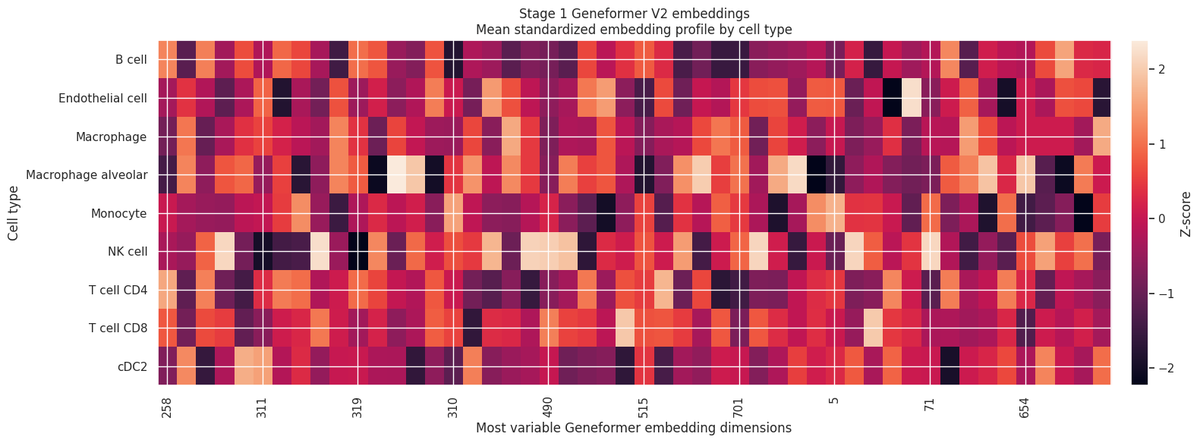

In [ ]:
#heatmap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Detect the 768 numeric embedding columns
embedding_cols = [
    col for col in stage1_embeddings.columns
    if col not in ["cell_id", "individual", "celltype", "disease"]
]

# Convert embedding columns to numeric
embedding_matrix = stage1_embeddings[embedding_cols].astype(float)

# Mean embedding per cell type
celltype_mean = (
    pd.concat(
        [
            stage1_embeddings[["celltype"]].reset_index(drop=True),
            embedding_matrix.reset_index(drop=True),
        ],
        axis=1,
    )
    .groupby("celltype", observed=True)
    .mean()
)

# Select most variable embedding dimensions
N_TOP_DIMS = 50

top_dims = (
    celltype_mean.var(axis=0)
    .sort_values(ascending=False)
    .head(N_TOP_DIMS)
    .index
)

heatmap_data = celltype_mean[top_dims].copy()

# Z-score each embedding dimension across cell types
heatmap_z = (
    heatmap_data - heatmap_data.mean(axis=0)
) / heatmap_data.std(axis=0).replace(0, np.nan)

heatmap_z = heatmap_z.fillna(0)

fig, ax = plt.subplots(figsize=(16, 6))

image = ax.imshow(
    heatmap_z.to_numpy(),
    aspect="auto",
    interpolation="nearest",
)

ax.set_yticks(np.arange(heatmap_z.shape[0]))
ax.set_yticklabels(heatmap_z.index)

# Avoid overcrowding x-axis
ax.set_xticks(np.arange(0, heatmap_z.shape[1], 5))
ax.set_xticklabels(
    [str(top_dims[i]) for i in range(0, len(top_dims), 5)],
    rotation=90,
)

ax.set_xlabel("Most variable Geneformer embedding dimensions")
ax.set_ylabel("Cell type")
ax.set_title(
    "Stage 1 Geneformer V2 embeddings\n"
    "Mean standardized embedding profile by cell type"
)

cbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Z-score")

plt.tight_layout()

heatmap_pdf = FIG_DIR / "stage1_celltype_embedding_heatmap.pdf"
heatmap_png = FIG_DIR / "stage1_celltype_embedding_heatmap.png"

plt.savefig(heatmap_pdf, dpi=100, bbox_inches="tight")
plt.savefig(heatmap_png, dpi=100, bbox_inches="tight")

plt.show()

print("Saved:")
print(heatmap_pdf)
print(heatmap_png)

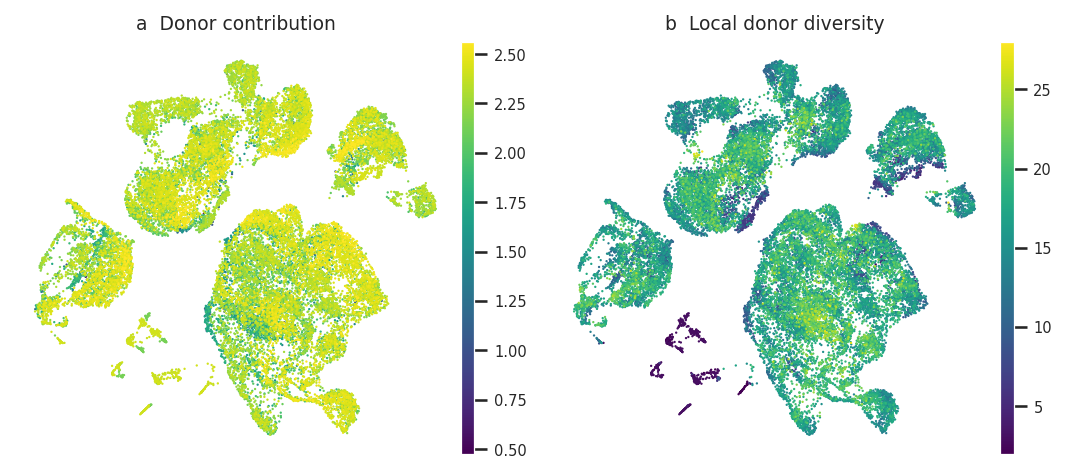

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

FIG_DIR = EMBED_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Nature-like plotting defaults
# -----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 100,
    "savefig.dpi": 100,
    "axes.linewidth": 0.6,
})

# Ensure UMAP exists
if "neighbors" not in adata_stage1.uns:
    sc.pp.neighbors(
        adata_stage1,
        n_neighbors=20,
        metric="cosine",
        use_rep="X",
        random_state=42,
    )

if "X_umap" not in adata_stage1.obsm:
    sc.tl.umap(
        adata_stage1,
        min_dist=0.25,
        spread=1.0,
        random_state=42,
    )

# -----------------------------
# 1. Donor contribution size
# -----------------------------
donor_counts = adata_stage1.obs["individual"].value_counts()

adata_stage1.obs["donor_cell_count"] = (
    adata_stage1.obs["individual"]
    .map(donor_counts)
    .astype(float)
)

adata_stage1.obs["log10_donor_cell_count"] = np.log10(
    adata_stage1.obs["donor_cell_count"] + 1
)

# -----------------------------
# 2. Local donor diversity
# -----------------------------
X = np.asarray(adata_stage1.X)

n_neighbors = 30

nn = NearestNeighbors(
    n_neighbors=n_neighbors + 1,
    metric="cosine",
    n_jobs=-1,
)

nn.fit(X)
neighbor_idx = nn.kneighbors(return_distance=False)[:, 1:]

donor_labels = adata_stage1.obs["individual"].astype(str).to_numpy()

local_unique_donors = np.array([
    len(np.unique(donor_labels[idx]))
    for idx in neighbor_idx
])

adata_stage1.obs["local_donor_diversity"] = local_unique_donors

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.2),
)

sc.pl.umap(
    adata_stage1,
    color="log10_donor_cell_count",
    ax=axes[0],
    show=False,
    frameon=False,
    size=5,
    cmap="viridis",
    title="a  Donor contribution",
    colorbar_loc="right",
)

axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

sc.pl.umap(
    adata_stage1,
    color="local_donor_diversity",
    ax=axes[1],
    show=False,
    frameon=False,
    size=5,
    cmap="viridis",
    title="b  Local donor diversity",
    colorbar_loc="right",
)

axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout(w_pad=1.2)

pdf_file = FIG_DIR / "stage1_donor_effect_umap_nature.pdf"
png_file = FIG_DIR / "stage1_donor_effect_umap_nature.png"

plt.savefig(pdf_file, bbox_inches="tight")
plt.savefig(png_file, bbox_inches="tight")
plt.show()

print("Saved:")
print(pdf_file)
print(png_file)

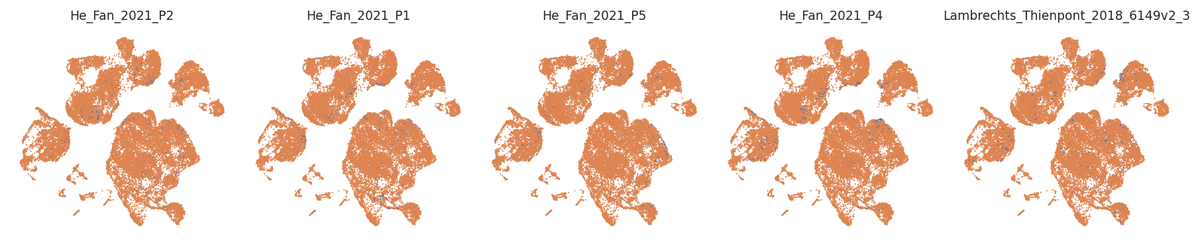

In [ ]:
top5_donors = (
    adata_stage1.obs["individual"]
    .value_counts()
    .head(5)
    .index
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 2.5),
)

for ax, donor in zip(axes, top5_donors):
    column = f"is_{donor}"

    adata_stage1.obs[column] = np.where(
        adata_stage1.obs["individual"] == donor,
        donor,
        "Other donors",
    )

    sc.pl.umap(
        adata_stage1,
        color=column,
        ax=ax,
        show=False,
        frameon=False,
        size=4,
        title=donor,
        legend_loc=None,
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

overlay_pdf = FIG_DIR / "stage1_top5_donor_overlays_nature.pdf"
overlay_png = FIG_DIR / "stage1_top5_donor_overlays_nature.png"

plt.savefig(overlay_pdf, bbox_inches="tight")
plt.savefig(overlay_png, bbox_inches="tight")
plt.show()

print("Saved:")
print(overlay_pdf)
print(overlay_png)

In [ ]:
#KNN donor purity
from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 30

nbrs = NearestNeighbors(
    n_neighbors=k+1,
    metric="cosine",
    n_jobs=-1
)

nbrs.fit(adata_stage1.X)

neighbors = nbrs.kneighbors(
    return_distance=False
)[:,1:]

donors = adata_stage1.obs["individual"].values

purity = []

for i, nn in enumerate(neighbors):

    same = np.sum(
        donors[nn] == donors[i]
    )

    purity.append(same / k)

adata_stage1.obs["donor_purity"] = purity

print("Mean donor purity:", np.mean(purity))
print("Median donor purity:", np.median(purity))

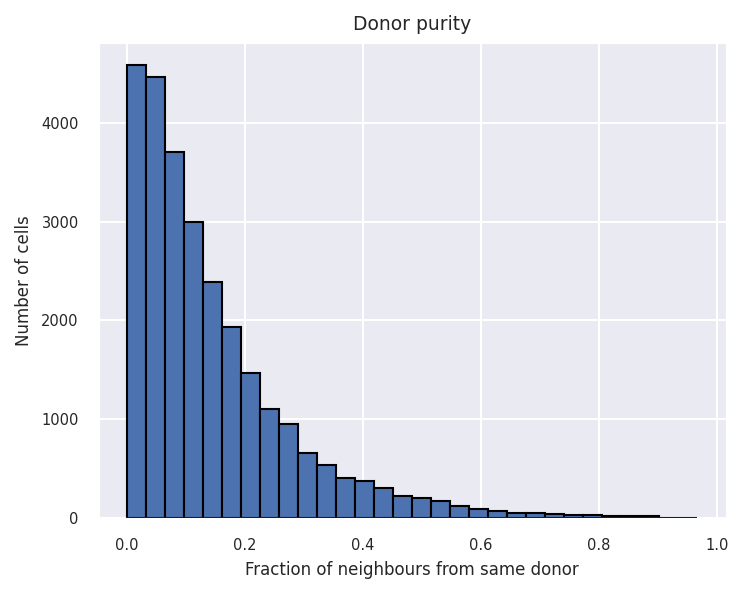

In [ ]:
#visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.hist(
    adata_stage1.obs["donor_purity"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Fraction of neighbours from same donor")
plt.ylabel("Number of cells")
plt.title("Donor purity")

plt.tight_layout()

plt.savefig(
    FIG_DIR/"donor_purity_histogram.pdf",
    dpi=100
)

plt.show()

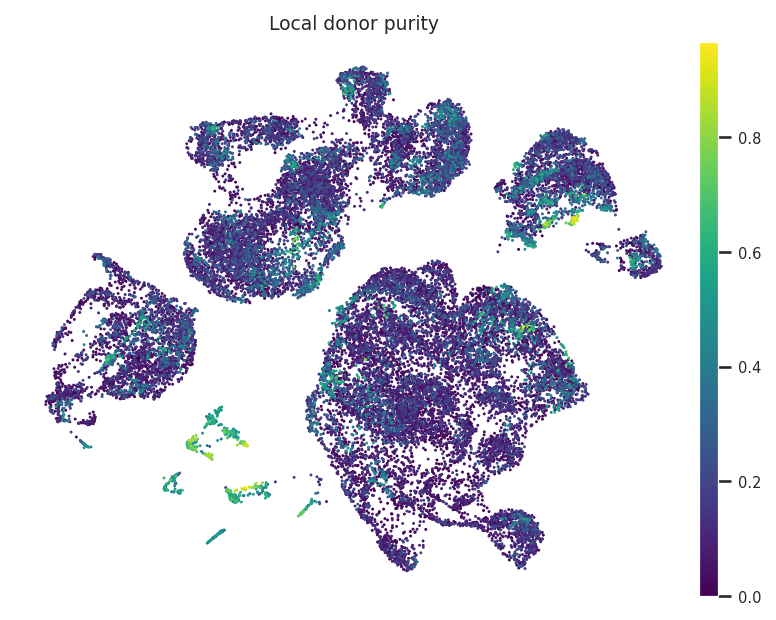

In [ ]:
#umap
sc.pl.umap(
    adata_stage1,
    color="donor_purity",
    cmap="viridis",
    size=8,
    frameon=False,
    title="Local donor purity"
)

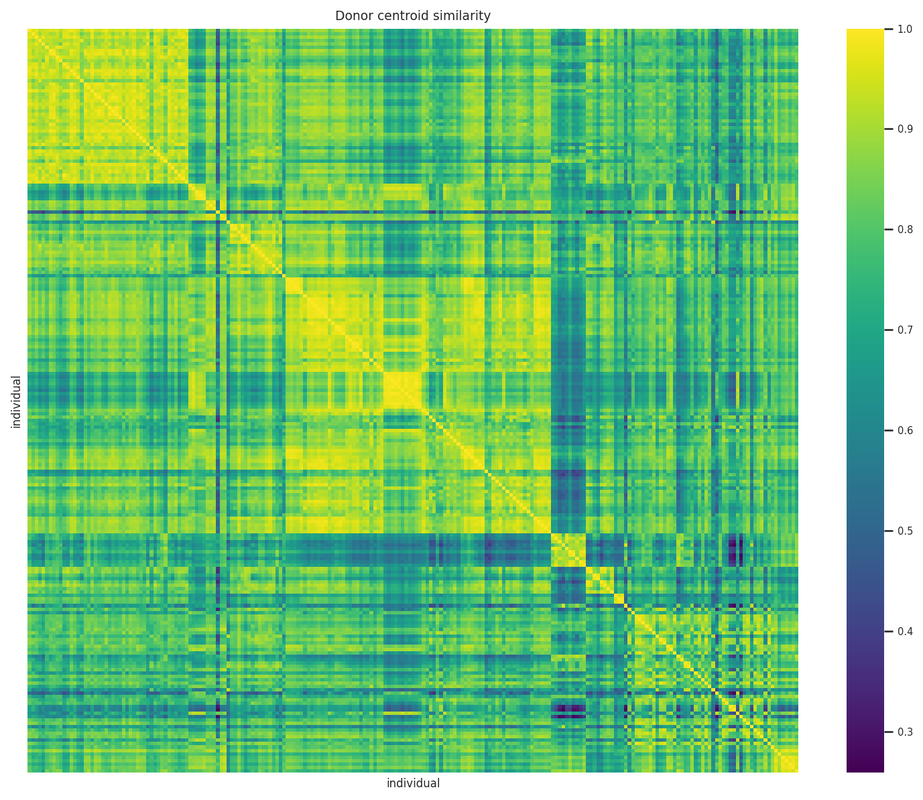

In [ ]:
#donor centroid
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import pandas as pd

emb = pd.DataFrame(
    adata_stage1.X,
    index=adata_stage1.obs["individual"]
)

centroids = emb.groupby(level=0).mean()

sim = cosine_similarity(centroids)

sim = pd.DataFrame(
    sim,
    index=centroids.index,
    columns=centroids.index
)

plt.figure(figsize=(10,8))

sns.heatmap(
    sim,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)

plt.title("Donor centroid similarity")

plt.tight_layout()

plt.savefig(
    FIG_DIR/"donor_similarity_heatmap.pdf",
    dpi=100
)

plt.show()

In [ ]:
#summary table
summary = pd.DataFrame({
    "Metric":[
        "Mean donor purity",
        "Median donor purity",
        "Donor silhouette"
    ],
    "Value":[
        np.mean(adata_stage1.obs["donor_purity"]),
        np.median(adata_stage1.obs["donor_purity"]),
        donor_score
    ]
})

display(summary)

summary.to_csv(
    FIG_DIR/"donor_leakage_summary.csv",
    index=False
)

In [ ]:
#chance adjusted donor enrichment
import numpy as np
import pandas as pd

donor_labels = adata_stage1.obs["individual"].astype(str)
donor_frequency = donor_labels.value_counts(normalize=True)

# Expected same-donor probability for each cell based only on donor abundance
expected_purity = donor_labels.map(donor_frequency).to_numpy(dtype=float)

observed_purity = adata_stage1.obs["donor_purity"].to_numpy(dtype=float)

# Difference above random expectation
adjusted_purity = observed_purity - expected_purity

# Ratio above random expectation
purity_enrichment = observed_purity / np.maximum(expected_purity, 1e-12)

adata_stage1.obs["expected_donor_purity"] = expected_purity
adata_stage1.obs["adjusted_donor_purity"] = adjusted_purity
adata_stage1.obs["donor_purity_enrichment"] = purity_enrichment

print(f"Observed mean purity:       {observed_purity.mean():.4f}")
print(f"Expected mean purity:       {expected_purity.mean():.4f}")
print(f"Chance-adjusted difference: {adjusted_purity.mean():.4f}")
print(f"Median enrichment ratio:    {np.median(purity_enrichment):.3f}×")

In [ ]:
#add to master table
MASTER_TABLE = EMBED_DIR / "embedding_master_table.csv"

master = pd.read_csv(MASTER_TABLE)

mask = master["Model"] == "Stage 1 Cell-type"

master.loc[mask, "Mean_Donor_Purity"] = round(
    float(np.mean(observed_purity)), 4
)
master.loc[mask, "Median_Donor_Purity"] = round(
    float(np.median(observed_purity)), 4
)
master.loc[mask, "Expected_Donor_Purity"] = round(
    float(np.mean(expected_purity)), 4
)
master.loc[mask, "Adjusted_Donor_Purity"] = round(
    float(np.mean(adjusted_purity)), 4
)
master.loc[mask, "Median_Donor_Enrichment"] = round(
    float(np.median(purity_enrichment)), 3
)

master.to_csv(MASTER_TABLE, index=False)

display(master)
print("Updated:", MASTER_TABLE)

In [ ]:
from IPython.display import Markdown, display
import numpy as np

def display_stage1_summary(
    celltype_score: float,
    disease_score: float,
    donor_score: float,
    observed_purity: np.ndarray,
    expected_purity: np.ndarray,
    adjusted_purity: np.ndarray,
    purity_enrichment: np.ndarray
):
    """
    Renders the Stage 1 Fine-tuning Summary in Jupyter Notebook using Markdown.
    Pass in your calculated float metrics and numpy arrays.
    """
    summary = f"""
# Stage 1 Fine-tuning Summary

## Objective

The first fine-tuning stage adapted **Geneformer V2** to classify **9 major lung cell types**
using **27,000 single cells** sampled from the integrated NSCLC atlas while minimizing donor
dominance through donor-aware sampling.

---

## Training Summary

| Parameter | Value |
|------------|-------|
| Base model | Geneformer V2 |
| Fine-tuning task | 9-class cell type classification |
| Training dataset | 01_primary_celltype |
| Training cells | 27,000 |
| Cell classes | 9 |
| Learning rate | 1 × 10⁻⁴ |
| Epochs | 1 |
| Frozen transformer layers | 6 |
| Train batch size | 8 |
| Forward batch size | 16 |

---

## Embedding Evaluation

| Metric | Value | Interpretation |
|----------|------:|----------------|
| Cell-type silhouette | **{celltype_score:.3f}** | Good separation of major cell types |
| Disease silhouette | **{disease_score:.3f}** | Minimal disease-specific organization |
| Donor silhouette | **{donor_score:.3f}** | No evidence of global donor-driven clustering |
| Mean donor purity | **{np.mean(observed_purity):.4f}** | Local donor enrichment |
| Median donor purity | **{np.median(observed_purity):.4f}** | Typical neighborhood donor purity |
| Expected donor purity | **{np.mean(expected_purity):.4f}** | Random expectation based on donor abundance |
| Adjusted donor purity | **{np.mean(adjusted_purity):.4f}** | Donor enrichment above random expectation |
| Median donor enrichment | **{np.median(purity_enrichment):.2f}×** | Fold enrichment over random expectation |

---

## Biological Interpretation

The Stage 1 fine-tuning successfully reorganized the Geneformer embedding space according to **cell identity**, producing clear separation of the nine major lung cell populations.

The **cell-type silhouette score ({celltype_score:.3f})** indicates good clustering of biologically related cell populations.

As expected, disease-specific information was not learned during Stage 1 because disease labels were not used for optimization. The disease silhouette remained close to zero (**{disease_score:.3f}**), indicating that the latent representation primarily captures cell identity rather than disease state.

Global donor effects were well controlled. The negative donor silhouette (**{donor_score:.3f}**) indicates that donor identity does not determine the global organization of the embedding space.

Neighborhood analysis detected moderate local donor enrichment (mean donor purity **{np.mean(observed_purity):.4f}**), which is expected in integrated single-cell atlases due to unequal donor representation and genuine biological variability.

Overall, Stage 1 achieved its intended objective of learning robust cell-type representations while minimizing large-scale donor-driven organization.

---

## Conclusion

**Stage 1 Fine-tuning: Successful**

*   ✅ Robust separation of major lung cell types.
*   ✅ Disease information remained largely absent, consistent with the training objective.
*   ✅ No evidence of substantial global donor leakage.
*   ✅ The resulting model provides an appropriate initialization for **Stage 2 disease-specific fine-tuning**.

---

## Workflow Progress
"""
    display(Markdown(summary))

# Run the function to render
# Render Stage 1 summary using the actual calculated results

display_stage1_summary(
    celltype_score=stage1_celltype_score,
    disease_score=stage1_disease_score,
    donor_score=stage1_donor_score,
    observed_purity=observed_purity,
    expected_purity=expected_purity,
    adjusted_purity=adjusted_purity,
    purity_enrichment=purity_enrichment,
)